# Ecoregions vs political units: how SOC, soil erosion & acidification LEAFs change with polygon size

The SBTN-Land LEAFs are published at three spatial **aggregation levels** that clip the
same underlying rasters to three different polygon sets:

| level | polygons | count |
|---|---|---|
| **country** | FAO ADM0 | 276 |
| **subcountry** | FAO ADM1 | 3 422 |
| **ecoregion** | WWF 2017 ecoregions | ~830–847 |

This notebook extends sections **6 (ecoregion significance — biomes & nested variance)**
and **7 (sensitivity heatmap)** of [`SoilErosion_Aggregation_Comparison.ipynb`](SoilErosion_Aggregation_Comparison.ipynb)
from one indicator to **three**, to answer one question directly:

> **Do ecoregions represent SOC, soil-erosion and terrestrial-acidification averages
> *differently* than sub-country or country units — and for which indicator do
> ecological boundaries matter most?**

| indicator | `leaf` value | unit | direction |
|---|---|---|---|
| **SOC** | 2030 soil-organic-carbon stock | t SOC/ha | higher = more carbon stored |
| **Soil erosion** | RUSLE soil loss | t soil/ha/yr | higher = worse |
| **Terrestrial acidification** | accumulated-exceedance CF (NOₓ, NH₃, SO₂) | kg SO₂-eq./kg | higher = worse |

All logic lives in `sbtn_leaf.claude_analysis` (engine: `indicator_aggregation`,
configs: `indicators`, comparison: `cross_indicator`); this notebook is the narrative
front-end. Tables and figures are also written to `paper/claude_analysis/outputs/` by
`xi.run_cross_indicator_analysis()` (last cell).

> **A note on the three indicators.** SOC and soil erosion are *land-use* LEAFs — one
> value per region **×** commodity/management — so they share the canonical flow key
> (`Commodity|water|residue|tillage`). Acidification is a *characterisation factor*
> defined region-wide for three acidifying gases, so its 'flows' are the gases. The
> aggregation machinery is identical; only the flow taxonomy differs.

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.width', 200, 'display.max_columns', 30)

from sbtn_leaf.claude_analysis import indicator_aggregation as eng
from sbtn_leaf.claude_analysis import cross_indicator as xi
from sbtn_leaf.claude_analysis.indicators import SOC, SOIL_EROSION, ACIDIFICATION, INDICATORS

# Harmonise every indicator onto the shared long schema. `raw` keeps the 'no data'
# cells so we can measure coverage; `data` drops them for the statistics.
raw  = {k: cfg.load_harmonized(drop_na=False) for k, cfg in INDICATORS.items()}
data = {k: r[r['leaf'].notna()].reset_index(drop=True) for k, r in raw.items()}

# A representative flow per indicator for the per-flow figures.
reps = {'soc': 'Wheat|rf|roff|ct', 'soil_erosion': 'Wheat|rf|roff|ct', 'acidification': 'acid_so2'}
data['soc'].head()

Could not determine dtype for column 1, falling back to string


,level,region_id,region_name,country_name,biome,realm,flow,flow_raw,leaf,leaf_median,leaf_std
0,country,Abyei,Abyei,Abyei,<NA>,<NA>,BRDC_Tropical,BRDC_Tropical_2030y_SOC,66.854030,66.327420,8.278654
1,country,Abyei,Abyei,Abyei,<NA>,<NA>,Banana|irr|na|ct,Banana_irr_2030y_SOC,18.301117,18.373402,0.347230
2,country,Abyei,Abyei,Abyei,<NA>,<NA>,Carrot|irr|na|ct,Carrot_irr_2030y_SOC,13.964627,13.983982,0.274893
3,country,Abyei,Abyei,Abyei,<NA>,<NA>,Cotton|irr|na|ct,Cotton_irr_2030y_SOC,13.894901,13.906025,0.243323
4,country,Abyei,Abyei,Abyei,<NA>,<NA>,Cotton|irr|na|rt,Cotton_irr_rt_2030y_SOC,20.896242,20.901081,0.305266


## 1. Harmonisation & coverage

Each indicator's source tables use different `flow_name` conventions and column layouts
(SOC `v1.0` tables carry a `variable` column; acidification tables carry a `metric`
column; the SOC ecoregion table even omits biome/realm, which we backfill). The engine
maps every spelling onto one canonical key and one `leaf`/`leaf_median`/`leaf_std` row
per region × flow, so the three indicators become directly comparable.

In [2]:
coverage = pd.concat(
    [eng.coverage_table(raw[k]).assign(indicator=cfg.name) for k, cfg in INDICATORS.items()],
    ignore_index=True,
)
coverage[['indicator', 'level', 'n_regions', 'n_flows', 'coverage_pct']].round(1)

,indicator,level,n_regions,n_flows,coverage_pct
0,SOC stock,country,276,110,48.0
1,SOC stock,subcountry,3422,110,51.1
2,SOC stock,ecoregion,796,110,63.2
3,Soil erosion,country,276,106,51.4
4,Soil erosion,subcountry,3422,106,58.0
5,Soil erosion,ecoregion,847,106,64.9
6,Acidification CF,country,276,3,100.0
7,Acidification CF,subcountry,3422,3,100.0
8,Acidification CF,ecoregion,829,3,100.0


Coverage (share of region × flow cells with a modelled value) **rises as polygons get
finer** for the two land-use indicators — SOC 48 → 51 → 63 %, soil erosion 51 → 58 → 65 %
— so ecologically defined polygons resolve the most land where commodities actually grow.
Acidification is ~100 % at every level because its characterisation factor is defined
for every region regardless of land use.

## 2. Cross-level summary statistics (mean / median / SD by level)

The core mean/median/SD comparison, for each indicator's focal flows. `mean_leaf`,
`median_leaf` and `std_leaf` are the **between-region** statistics; `mean_within_std`
is the mean per-region `leaf_std` (typical **within-region** heterogeneity); `cv` is the
between-region coefficient of variation.

In [3]:
combined = xi.combined_summary_table()
combined[['indicator_name', 'flow_label', 'level', 'n_regions', 'mean_leaf',
          'median_leaf', 'std_leaf', 'mean_within_std', 'cv']].round(2)

,indicator_name,flow_label,level,n_regions,mean_leaf,median_leaf,std_leaf,mean_within_std,cv
0,SOC stock,Broadleaf-decid. forest (tropical),country,97,90.79,80.39,46.25,25.37,0.51
1,SOC stock,Broadleaf-decid. forest (tropical),subcountry,1378,89.19,78.28,47.69,16.87,0.53
2,SOC stock,Broadleaf-decid. forest (tropical),ecoregion,419,100.07,88.63,47.72,26.32,0.48
3,SOC stock,Coffee (rainfed),country,86,41.11,37.76,14.53,6.86,0.35
4,SOC stock,Coffee (rainfed),subcountry,1138,39.93,37.22,12.78,5.14,0.32
...,...,...,...,...,...,...,...,...,...
58,Acidification CF,NOₓ (acidification),subcountry,3422,0.38,0.26,0.31,0.03,0.81
59,Acidification CF,NOₓ (acidification),ecoregion,829,0.33,0.21,0.30,0.06,0.92
60,Acidification CF,SO₂ (acidification),country,276,0.92,0.65,0.89,0.27,0.97
61,Acidification CF,SO₂ (acidification),subcountry,3422,1.10,0.83,0.93,0.14,0.85


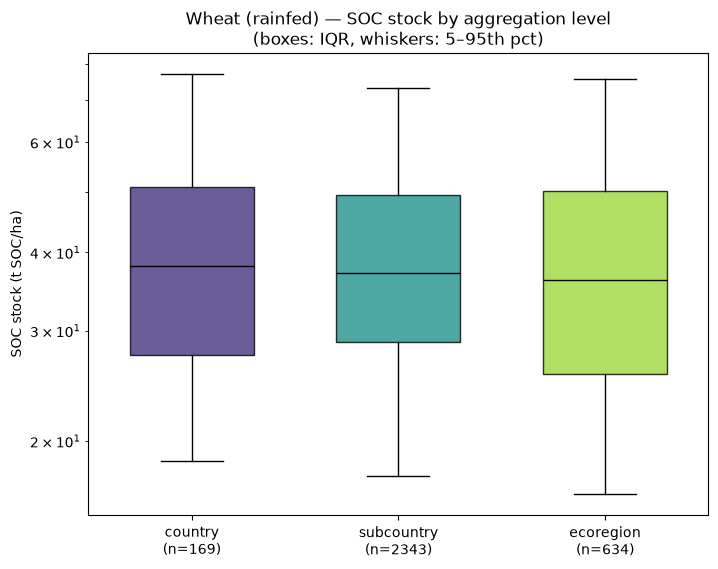

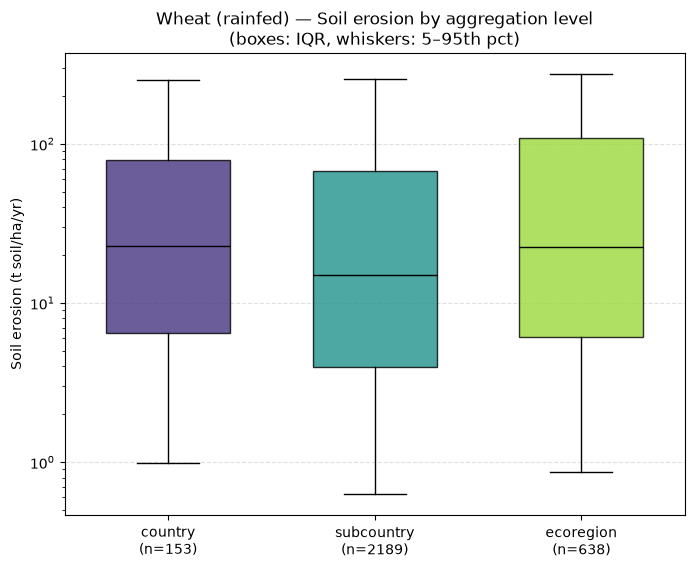

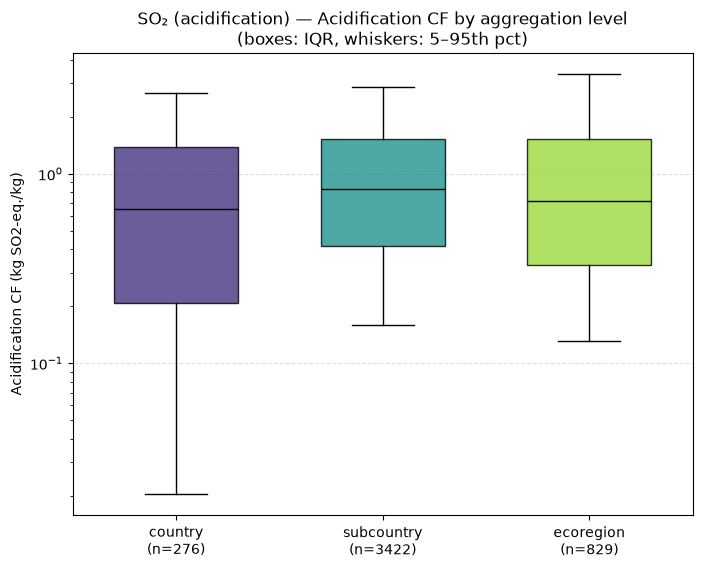

In [4]:
# Cross-level boxplots for one representative flow per indicator
for k, flow in reps.items():
    fig, ax = eng.plot_cross_level_box(INDICATORS[k], data[k], flow)
    display(fig); plt.close(fig)

The boxes show how the **published value's spread depends on polygon size**. For the
land-use indicators the country boxes are compressed toward the middle, while finer
polygons expose a longer tail — the hotspots national averages hide.

## 3. Ecoregion significance — biomes and nested variance

*(the section-6 analogue, now across three indicators)*

Two complementary views:

* **Biome breakdown** — ecoregion `leaf` for the representative flow, split by WWF biome.
  Clear separation between biomes means the ecological grouping carries real signal.
* **Nested variance decomposition** —
  * `subcty_within_country_frac`: the share of admin-1 variance a single **national** LEAF
    hides inside its sub-units (the cost of political coarsening).
  * `eco_between_biome_eta2` / `eco_between_realm_eta2`: the share of ecoregion variance
    **explained** by biome / realm (ecoregion significance).

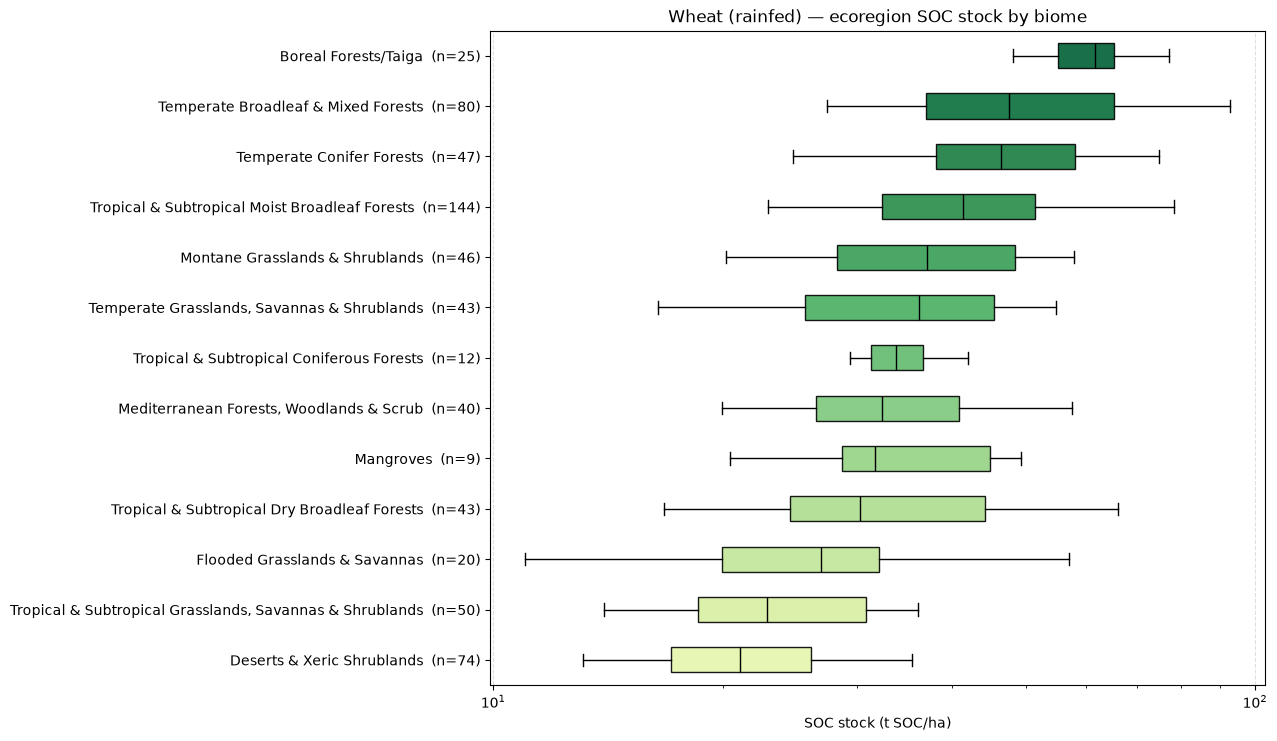

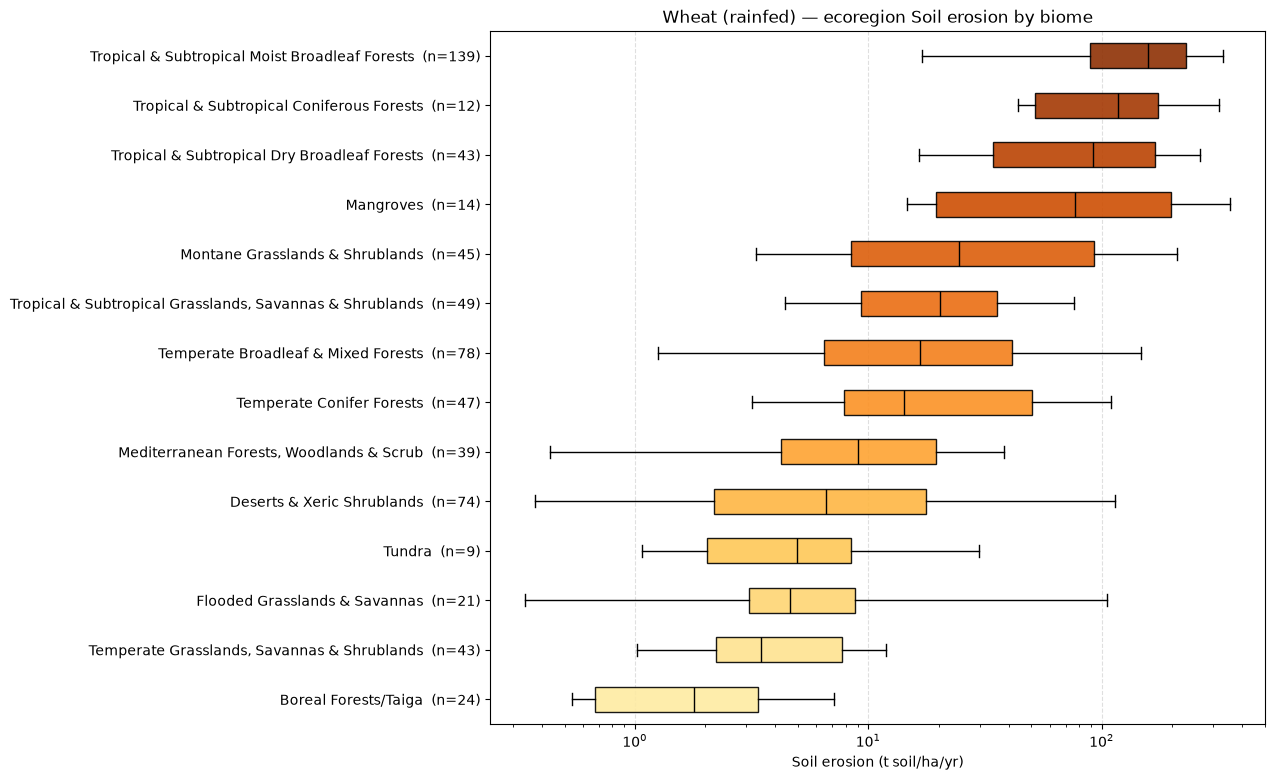

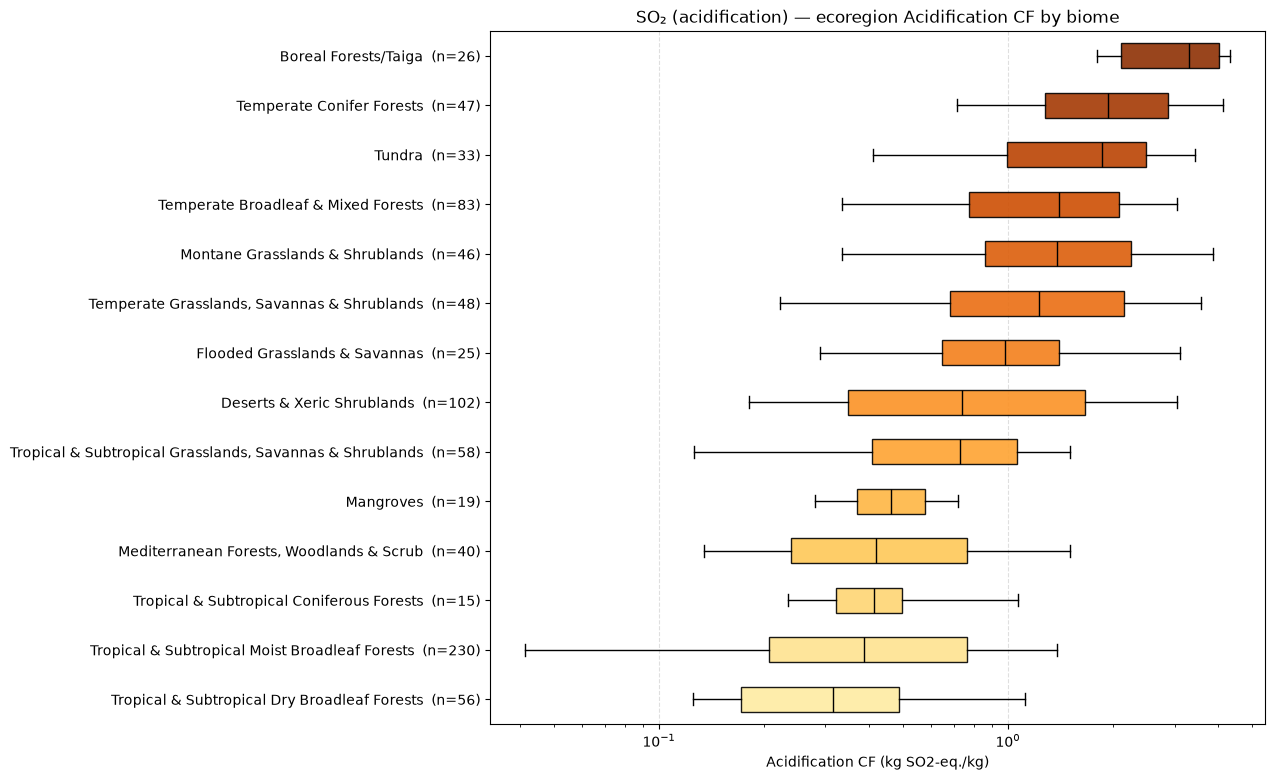

In [5]:
for k, flow in reps.items():
    fig, ax = eng.plot_biome_box(INDICATORS[k], data[k], flow)
    display(fig); plt.close(fig)

In [6]:
# Per-indicator nested variance across each indicator's focal flows
variance = pd.concat(
    [eng.hierarchy_variance_table(cfg, data[k], flows=list(cfg.focal_flows))
     for k, cfg in INDICATORS.items()],
    ignore_index=True,
)
variance.round(3)

,indicator,flow,flow_label,subcty_within_country_frac,subcty_n_units,eco_between_biome_eta2,eco_between_realm_eta2,eco_n_units
0,soc,Wheat|rf|roff|ct,Wheat (rainfed),0.224,2343,0.330,0.120,633
1,soc,Maize|rf|roff|ct,Maize (rainfed),0.202,2837,0.239,0.182,694
2,soc,Soybeans|rf|na|ct,Soybeans (rainfed),0.357,1960,0.239,0.194,595
3,soc,Oil_palm|rf|na|ct,Oil palm (rainfed),0.507,677,0.095,0.338,242
4,soc,Coffee|rf|na|ct,Coffee (rainfed),0.302,1138,0.089,0.274,358
5,soc,Sugarcane|rf|na|ct,Sugarcane (rainfed),0.405,1292,0.059,0.171,416
6,soc,Cotton|rf|na|ct,Cotton (rainfed),0.393,1512,0.167,0.134,504
7,soc,Grassland,Grassland,0.304,2499,0.248,0.076,705
8,soc,BRDC_Tropical,Broadleaf-decid. forest (tropical),0.323,1378,0.092,0.146,418
9,soil_erosion,Wheat|rf|roff|ct,Wheat (rainfed),0.234,2189,0.430,0.316,637


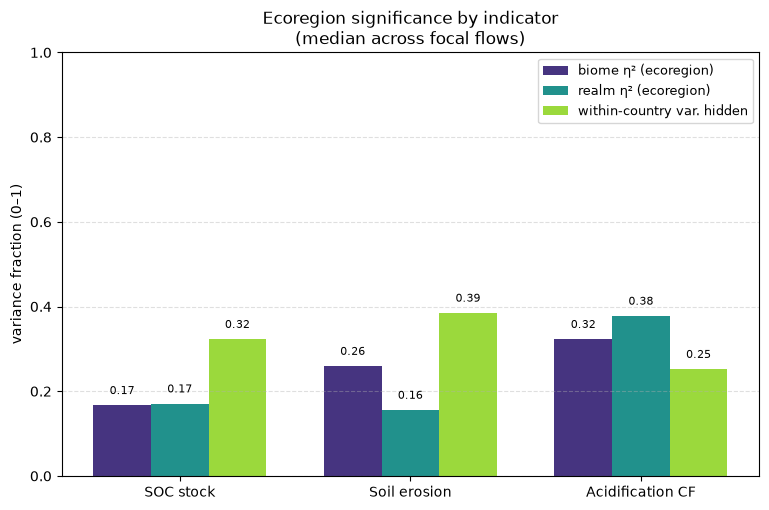

,indicator,indicator_name,unit,n_focal_flows,eco_biome_eta2,eco_realm_eta2,subcty_within_country_frac
0,soc,SOC stock,t SOC/ha,9,0.167,0.171,0.323
1,soil_erosion,Soil erosion,t soil/ha/yr,9,0.260,0.156,0.385
2,acidification,Acidification CF,kg SO2-eq./kg,3,0.323,0.378,0.252


In [7]:
fig, ax = xi.plot_significance_comparison(); display(fig); plt.close(fig)
xi.significance_table().round(3)

**This is the headline result.** Summarised across each indicator's focal flows (median):

| indicator | biome η² | realm η² | within-country hidden |
|---|---|---|---|
| SOC stock | 0.17 | 0.17 | 0.32 |
| Soil erosion | 0.26 | 0.16 | 0.39 |
| Acidification | **0.32** | **0.38** | 0.25 |

* **Acidification is the most 'ecological' indicator.** Biome and realm explain the
  *largest* share of ecoregion variance (realm η² for NOₓ reaches **0.52**), because the
  acidification CF is driven by soil sensitivity and atmospheric fate, which track
  climatic/ecological gradients closely. For acidification, an ecoregion average is
  genuinely more representative than a national one.
* **Soil erosion hides the most inside national borders** (within-country fraction 0.39):
  a single country LEAF averages away the largest slice of real sub-national erosion
  contrast — so country-level erosion LEAFs are the least representative of the three.
* **SOC is the most locally driven.** Biome explains the least (0.17): SOC stock varies
  more with local soil type than with broad ecological zones, so neither political nor
  ecological polygons capture it cleanly — though oil-palm SOC still hides **0.51** of its
  variance within countries (perennials in heterogeneous tropics).

## 4. Sensitivity heatmaps

*(the section-7 analogue)* — a compact view of mean `leaf` across flow × level (log
colour scale) for each indicator. Reading left→right shows how the central estimate of
every flow shifts as polygons shrink country → subcountry → ecoregion.

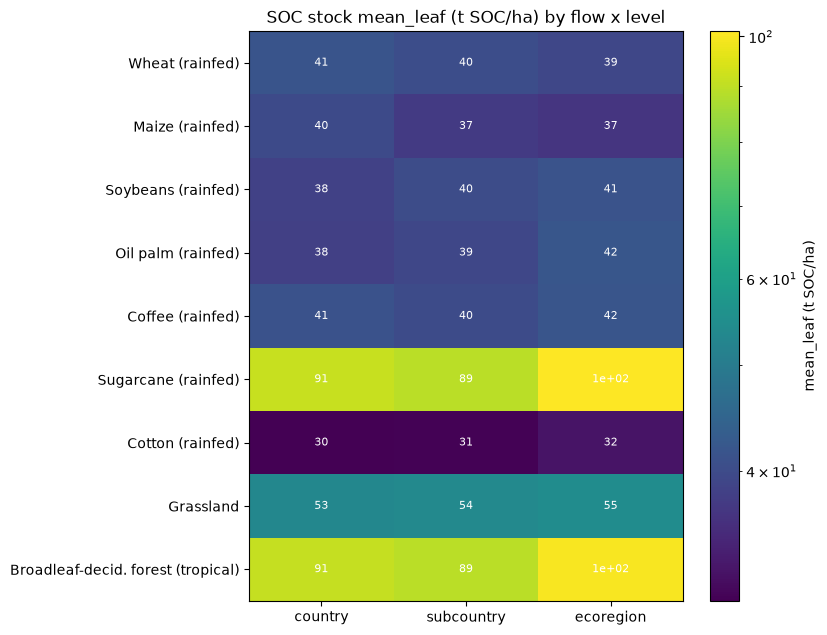

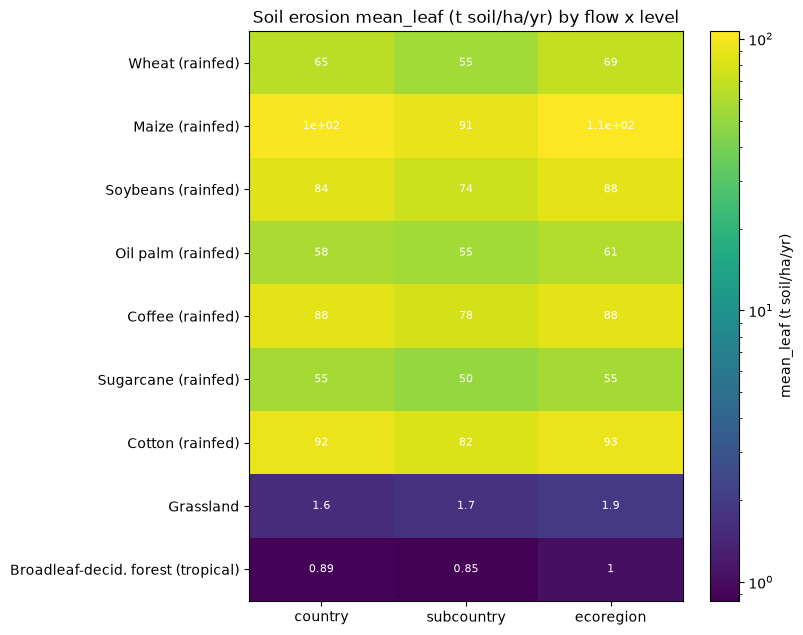

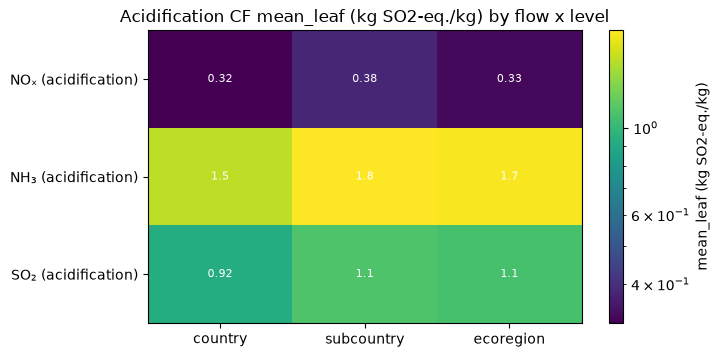

In [8]:
for k, cfg in INDICATORS.items():
    fig, ax = eng.plot_sensitivity_heatmap(cfg, data[k])
    display(fig); plt.close(fig)

Within an indicator the **ranking of commodities is stable across levels** (a column
re-colours but the row order barely changes), confirming the level choice reframes the
*magnitude* of the average more than the *ordering* of which land uses are most
carbon-rich / erosive / acidifying.

## 5. How ecoregions reframe the average

The most direct answer to the question. Because the three indicators have different
units, each focal flow's level means are normalised to its **own country mean
(country = 1.0)** and then summarised (median) across focal flows.

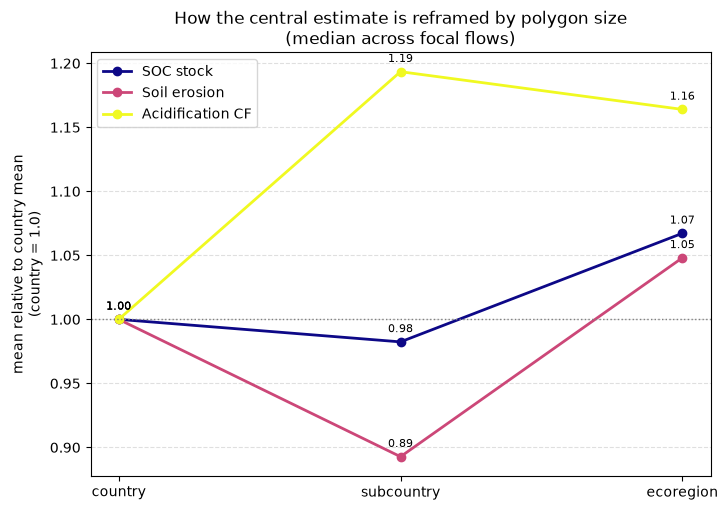

,indicator,indicator_name,unit,rel_mean_country,rel_median_country,rel_mean_subcountry,rel_median_subcountry,rel_mean_ecoregion,rel_median_ecoregion
0,soc,SOC stock,t SOC/ha,1.0,1.0,0.982,0.975,1.067,1.033
1,soil_erosion,Soil erosion,t soil/ha/yr,1.0,1.0,0.893,0.887,1.048,1.045
2,acidification,Acidification CF,kg SO2-eq./kg,1.0,1.0,1.193,1.263,1.164,1.104


In [9]:
fig, ax = xi.plot_level_reframing(); display(fig); plt.close(fig)
xi.level_reframing_table().round(3)

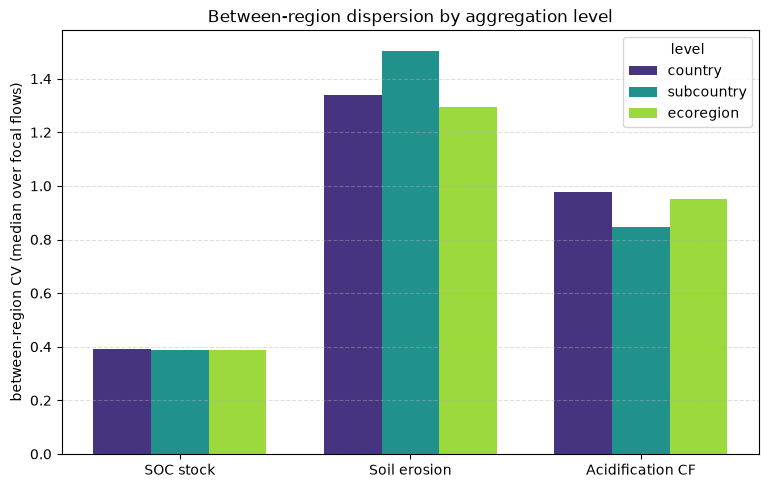

,indicator,indicator_name,cv_country,cv_subcountry,cv_ecoregion
0,soc,SOC stock,0.393,0.386,0.387
1,soil_erosion,Soil erosion,1.338,1.505,1.294
2,acidification,Acidification CF,0.979,0.846,0.952


In [10]:
fig, ax = xi.plot_dispersion_by_level(); display(fig); plt.close(fig)
xi.dispersion_table().round(3)

* **Ecoregion averages run higher than national ones** for all three indicators (mean
  relative to country: SOC 1.07, erosion 1.05, acidification 1.16). National averaging
  dilutes the high-value regions; ecoregions restore them. For acidification the gap
  opens already at the subcountry level (1.19) — political aggregation understates the
  CF by ~15–20 %.
* **Sub-country is not simply 'between' country and ecoregion.** For SOC and soil erosion
  the subcountry mean dips *below* the country mean (0.98 / 0.89) before the ecoregion
  mean rises above it — admin-1 polygons fragment commodities into their lower-value
  growing margins, while ecoregions re-aggregate along the ecological gradient.
* **Dispersion behaves differently per indicator.** SOC's between-region CV is flat
  (~0.39) — SOC stock is similarly variable at every scale. Soil erosion peaks at
  subcountry (CV 1.50): admin-1 polygons slice through erosion hotspots. Acidification
  dispersion dips at subcountry, consistent with its strong realm-level structure.

## 6. Findings

1. **Ecoregions are the most informative level for acidification, the most *necessary*
   for soil erosion, and the least decisive for SOC.** Ecological grouping explains a
   third of acidification variance but only a sixth of SOC variance; soil erosion is the
   indicator a national LEAF most badly misrepresents (39 % of variance hidden
   within-country).
2. **Ecoregion averages are systematically higher than national averages** (5–16 %),
   because country polygons average commodity hotspots together with the land around
   them. Using a country LEAF therefore tends to *understate* SOC opportunity, erosion
   risk and acidification impact alike.
3. **Coverage favours ecoregions too**: for the land-use indicators ecoregions resolve
   ~13–14 percentage points more of the region × commodity grid than countries do.
4. **Practical guidance** (consistent with `LEAFs/README.md`'s 'country as last resort'):
   prefer the ecoregion LEAF where an ecological signal dominates (acidification, and
   biome-structured erosion); fall back to subcountry where commodity-specific local
   detail matters more than the ecological gradient (much of SOC).

## 7. Reproduce all artifacts

Regenerates every table and figure under `paper/claude_analysis/outputs/` and rewrites
the findings `README.md` (also available from the CLI:
`python -m sbtn_leaf.claude_analysis.run_cross_indicator`).

In [11]:
result = xi.run_cross_indicator_analysis()
print('Wrote artifacts to:', result['outdir'])
result['significance'].round(3)

Wrote artifacts to: /home/user/SBTN_Land_LEAFs/paper/claude_analysis/outputs


,indicator,indicator_name,unit,n_focal_flows,eco_biome_eta2,eco_realm_eta2,subcty_within_country_frac
0,soc,SOC stock,t SOC/ha,9,0.167,0.171,0.323
1,soil_erosion,Soil erosion,t soil/ha/yr,9,0.260,0.156,0.385
2,acidification,Acidification CF,kg SO2-eq./kg,3,0.323,0.378,0.252
